# **Bias in Drug Reaction - 02**
## **Model Training, Evaluation & Ablation Study**

This notebook trains and evaluates machine learning models to predict
whether a drug adverse event is serious or not, using the cleaned FAERS
dataset from Notebook 01.

## What we do here

- `Split` the data into train (60%), validation (20%), and test (20%) sets.

- `Encode` features (drug, reaction, sex, age) all encoders fit on train only to prevent leakage.

- `Train 4 models:` Logistic Regression and XGBoost, each with and without the reaction feature.

- `Ablation study:` we compare Model A (with reaction) vs Model B (without reaction) to check if the reaction feature acts as a proxy variable, if fairness gaps persist without it, the bias is in the data itself.

- `Tune XGBoost` on the train set using RandomizedSearchCV (cv=5).

- `Select threshold` on the validation set only clinical justification:
  missing a serious case (false negative) is more harmful than a false alarm.

> `XGB tuned: Without reaction feature`, threshold = 0.5


---



In [3]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
!pip install xgboost --quiet
import pickle, json, os, warnings
warnings.filterwarnings('ignore')


os.makedirs(PLOTS_PATH, exist_ok=True)

df = pd.read_csv(PROCESSED_PATH + 'df_clean.csv')

print('=' * 55)
print('DATA LOADED FROM NOTEBOOK 01')
print('=' * 55)
print(f'Rows         : {len(df):,}')
print(f'Columns      : {df.columns.tolist()}')
print(f'Serious rate : {df["serious"].mean():.1%}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA LOADED FROM NOTEBOOK 01
Rows         : 141,472
Columns      : ['primaryid', 'age_years', 'sex', 'serious', 'reaction', 'drug_name', 'age_group']
Serious rate : 55.1%


In [4]:
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.metrics          import (
    classification_report, roc_auc_score,
    confusion_matrix, roc_curve,
    accuracy_score, f1_score,
    recall_score, precision_score)
from scipy.stats import fisher_exact
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'figure.dpi'       : 150,
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

---
## **Reason Behind Ablation Study: Reaction Feature Analysis**

During the data exploration phase, we identified a potential methodological concern with the `reaction` feature derived from the FAERS `REAC` file.

### **The Problem**

The `reaction` column contains the adverse reaction reported by the patient or clinician, for example, *"nausea"*, *"headache"*, or *"cardiac arrest"*. Our target variable `serious` is derived separately from the `OUTC` file, where outcomes like death, hospitalisation, and life-threatening events are recorded.

At first glance these two sources appear independent. However, we observed that certain reaction terms such as *"death"*, *"cardiac arrest"*, *"respiratory failure"*, and *"sepsis"*   are almost always associated with a `serious = 1` label. This creates a near-circular relationship: the model could learn to predict seriousness simply by detecting these terms in the reaction field, without genuinely understanding the underlying patient risk factors.

This is known as a **proxy variable problem**. The reaction feature is not truly a cause of seriousness, it is an alternate description of the same event recorded in a different file. Including it risks making the model a near-tautology rather than a genuine predictive system.

### The Impact on Fairness

Beyond model validity, this concern has a direct fairness implication. If the model relies heavily on reaction terms to make predictions, the influence of genuinely demographic features, patient age and sex becomes suppressed. Any fairness disparities we observe could then be an artefact of the reaction feature rather than a true reflection of bias in how the data represents different patient groups.

### Our Solution: Ablation Study

To address this, we trained two parallel model variants:

- **Model A**: trained with the reaction feature included
- **Model B**: trained with the reaction feature removed (ablation model)

By comparing the fairness metrics of both models, we can determine whether the observed demographic disparities are genuine data-level bias or an artefact introduced by the reaction proxy. If the fairness gap persists in Model B, the bias is rooted in the training data itself, which is a stronger and more defensible claim for an ethics audit.

---

In [5]:
# ============================================================
# Checking Reaction Overlap With Target
# Confirms why ablation study is needed
# ============================================================

print('=' * 55)
print('REACTION OVERLAP CHECK')
print('=' * 55)

clearly_serious_terms = [
    'death', 'cardiac arrest', 'respiratory failure',
    'sepsis', 'renal failure', 'hepatic failure',
    'multi-organ failure', 'sudden death'
]

pattern      = '|'.join(clearly_serious_terms)
overlap_mask = df['reaction'].str.contains(pattern, case=False, na=False)
overlap_df   = df[overlap_mask]
non_overlap  = df[~overlap_mask]

print(f'Total rows                         : {len(df):,}')
print(f'Rows with clearly serious reaction : {len(overlap_df):,} ({len(overlap_df)/len(df):.1%})')
print(f'Rows with ambiguous reaction       : {len(non_overlap):,} ({len(non_overlap)/len(df):.1%})')
print()
print(f'Serious rate in overlap rows       : {overlap_df["serious"].mean():.1%}')
print(f'Serious rate in non-overlap rows   : {non_overlap["serious"].mean():.1%}')
print()
print('Top clearly serious reactions found:')
print(overlap_df['reaction'].value_counts().head(10).to_string())
print()
rate = overlap_df['serious'].mean()
if rate > 0.85:
    print('HIGH overlap: Ablation study is necessary')
elif rate > 0.70:
    print('MODERATE overlap: Ablation study recommended')
else:
    print('LOW overlap: reaction is safe as feature')

REACTION OVERLAP CHECK
Total rows                         : 141,472
Rows with clearly serious reaction : 7,972 (5.6%)
Rows with ambiguous reaction       : 133,500 (94.4%)

Serious rate in overlap rows       : 96.6%
Serious rate in non-overlap rows   : 52.6%

Top clearly serious reactions found:
reaction
death                        6240
sepsis                        345
cardiac arrest                343
renal failure                 254
respiratory failure           221
hepatic failure               101
acute hepatic failure          94
acute respiratory failure      91
sudden death                   60
urosepsis                      44

HIGH overlap: Ablation study is necessary


### TRAIN / VALIDATION / TEST SPLIT

In [6]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT  (60 / 20 / 20)
# ============================================================
# Train  (60%): model learns from this
# Val    (20%): threshold selection + hyperparameter tuning
# Test   (20%): touched ONCE at the very end for final report
#
# This eliminates test-set leakage through model selection
# ============================================================

print('=' * 55)
print('TRAIN / VALIDATION / TEST SPLIT  60/20/20')
print('=' * 55)

# Step 1: split off test set (20%)
temp_df, test_df = train_test_split(
    df,
    test_size    = 0.2,
    random_state = RANDOM_SEED,
    stratify     = df['serious']
)

# Step 2: split remaining 80% into train (75% of 80%=60%) and val (25% of 80%=20%)
train_df, val_df = train_test_split(
    temp_df,
    test_size    = 0.25,
    random_state = RANDOM_SEED,
    stratify     = temp_df['serious']
)

train_df = train_df.copy().reset_index(drop=True)
val_df   = val_df.copy().reset_index(drop=True)
test_df  = test_df.copy().reset_index(drop=True)

print(f'Train : {len(train_df):,} rows  ({train_df["serious"].mean():.1%} serious)')
print(f'Val   : {len(val_df):,} rows   ({val_df["serious"].mean():.1%} serious)')
print(f'Test  : {len(test_df):,} rows   ({test_df["serious"].mean():.1%} serious)')

# Leakage checks
assert len(set(train_df['primaryid']) & set(test_df['primaryid'])) == 0
assert len(set(train_df['primaryid']) & set(val_df['primaryid']))  == 0
assert len(set(val_df['primaryid'])   & set(test_df['primaryid'])) == 0
print('Leakage check passed: no primaryid overlap across all 3 sets')


TRAIN / VALIDATION / TEST SPLIT  60/20/20
Train : 84,882 rows  (55.1% serious)
Val   : 28,295 rows   (55.1% serious)
Test  : 28,295 rows   (55.1% serious)
Leakage check passed: no primaryid overlap across all 3 sets


In [7]:
# ============================================================
# WHY TOP_N: Coverage Analysis
# ============================================================

print('=' * 55)
print('DRUG COVERAGE ANALYSIS')
print('=' * 55)

total_drug_reports = len(train_df)

for n in [50, 100, 150, 200, 300, 500]:
    top_n = train_df['drug_name'].value_counts().head(n).index
    coverage = train_df['drug_name'].isin(top_n).mean()
    unique_drugs = train_df['drug_name'].nunique()
    print(f'Top {n:>4} drugs : {coverage:.1%} coverage '
          f'(out of {unique_drugs:,} unique drugs)')

print()
print('=' * 55)
print('REACTION COVERAGE ANALYSIS')
print('=' * 55)

for n in [50, 100, 150, 200, 300]:
    top_n = train_df['reaction'].value_counts().head(n).index
    coverage = train_df['reaction'].isin(top_n).mean()
    unique_reactions = train_df['reaction'].nunique()
    print(f'Top {n:>4} reactions: {coverage:.1%} coverage '
          f'(out of {unique_reactions:,} unique reactions)')

DRUG COVERAGE ANALYSIS
Top   50 drugs : 34.3% coverage (out of 3,143 unique drugs)
Top  100 drugs : 47.4% coverage (out of 3,143 unique drugs)
Top  150 drugs : 55.9% coverage (out of 3,143 unique drugs)
Top  200 drugs : 61.8% coverage (out of 3,143 unique drugs)
Top  300 drugs : 70.4% coverage (out of 3,143 unique drugs)
Top  500 drugs : 81.2% coverage (out of 3,143 unique drugs)

REACTION COVERAGE ANALYSIS
Top   50 reactions: 29.3% coverage (out of 5,702 unique reactions)
Top  100 reactions: 40.1% coverage (out of 5,702 unique reactions)
Top  150 reactions: 48.0% coverage (out of 5,702 unique reactions)
Top  200 reactions: 53.7% coverage (out of 5,702 unique reactions)
Top  300 reactions: 61.7% coverage (out of 5,702 unique reactions)


In [8]:
# ============================================================
# ENCODING: Fit on TRAIN only
# + StandardScaler for Logistic Regression
# ============================================================

TOP_N_DRUGS     = 300
TOP_N_REACTIONS = 200

# ── Drug encoding ────────────────────────────────────────
top_drugs = (train_df['drug_name'].value_counts()
             .head(TOP_N_DRUGS).index.tolist())
for df_ in [train_df, val_df, test_df]:
    df_['drug_encoded'] = df_['drug_name'].where(
        df_['drug_name'].isin(top_drugs), 'other')

le_drug = LabelEncoder()
le_drug.fit(train_df['drug_encoded'])

def safe_transform(encoder, values):
    known  = set(encoder.classes_)
    mapped = [v if v in known else 'other' for v in values]
    return encoder.transform(mapped)

train_df['drug_enc'] = le_drug.transform(train_df['drug_encoded'])
val_df['drug_enc']   = safe_transform(le_drug, val_df['drug_encoded'])
test_df['drug_enc']  = safe_transform(le_drug, test_df['drug_encoded'])

# ── Reaction encoding ────────────────────────────────────
top_reactions = (train_df['reaction'].value_counts()
                 .head(TOP_N_REACTIONS).index.tolist())
for df_ in [train_df, val_df, test_df]:
    df_['reaction_encoded'] = df_['reaction'].where(
        df_['reaction'].isin(top_reactions), 'other')

le_reaction = LabelEncoder()
le_reaction.fit(train_df['reaction_encoded'])
train_df['reaction_enc'] = le_reaction.transform(train_df['reaction_encoded'])
val_df['reaction_enc']   = safe_transform(le_reaction, val_df['reaction_encoded'])
test_df['reaction_enc']  = safe_transform(le_reaction, test_df['reaction_encoded'])

# ── Sex and age encoding ─────────────────────────────────
AGE_GROUP_MAP = {'paediatric':0, 'young_adult':1, 'middle_aged':2, 'elderly':3}
for df_ in [train_df, val_df, test_df]:
    df_['sex_binary']    = (df_['sex'] == 'M').astype(int)
    df_['age_group_enc'] = df_['age_group'].map(AGE_GROUP_MAP)

print('Encoding done')

# ── Feature matrices ─────────────────────────────────────
FEATURES_A = ['age_years', 'sex_binary', 'age_group_enc', 'reaction_enc', 'drug_enc']
FEATURES_B = ['age_years', 'sex_binary', 'age_group_enc', 'drug_enc']

X_train_A = train_df[FEATURES_A].values
X_val_A   = val_df[FEATURES_A].values
X_test_A  = test_df[FEATURES_A].values

X_train_B = train_df[FEATURES_B].values
X_val_B   = val_df[FEATURES_B].values
X_test_B  = test_df[FEATURES_B].values

y_train = train_df['serious'].values
y_val   = val_df['serious'].values
y_test  = test_df['serious'].values

# ── StandardScaler for LR fit on train ONLY ────────────
# LR is scale-sensitive: age_years (0-110) vs sex_binary (0-1)
scaler_A = StandardScaler()
scaler_B = StandardScaler()

X_train_A_sc = scaler_A.fit_transform(X_train_A)
X_val_A_sc   = scaler_A.transform(X_val_A)
X_test_A_sc  = scaler_A.transform(X_test_A)

X_train_B_sc = scaler_B.fit_transform(X_train_B)
X_val_B_sc   = scaler_B.transform(X_val_B)
X_test_B_sc  = scaler_B.transform(X_test_B)

print(f'X_train_A : {X_train_A.shape}  (XGBoost — unscaled)')
print(f'X_train_B : {X_train_B.shape}  (XGBoost — unscaled)')
print(f'X_train_A_sc : {X_train_A_sc.shape}  (LR — scaled)')
print(f'X_train_B_sc : {X_train_B_sc.shape}  (LR — scaled)')

for arr, name in [(X_train_A,'X_train_A'),(X_val_A,'X_val_A'),(X_test_A,'X_test_A'),
                   (X_train_B,'X_train_B'),(X_val_B,'X_val_B'),(X_test_B,'X_test_B')]:
    assert not np.isnan(arr).any(), f'NaN in {name}'
print('No NaN in any feature matrix')
print('Scalers fitted on train only')

Encoding done
X_train_A : (84882, 5)  (XGBoost — unscaled)
X_train_B : (84882, 4)  (XGBoost — unscaled)
X_train_A_sc : (84882, 5)  (LR — scaled)
X_train_B_sc : (84882, 4)  (LR — scaled)
No NaN in any feature matrix
Scalers fitted on train only


In [9]:
# ============================================================
# TRAIN ALL 4 MODELS
# LR uses scaled features
# XGBoost uses unscaled features
# ============================================================

print('=' * 55)
print('TRAINING ALL 4 MODELS')
print('=' * 55)

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

# LR: uses SCALED features
print('Training LR-A  (with reaction, scaled)')
lr_A = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced')
lr_A.fit(X_train_A_sc, y_train)


print('Training LR-B  (without reaction, scaled)')
lr_B = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced')
lr_B.fit(X_train_B_sc, y_train)


# XGBoost: uses UNSCALED features (tree-based, scale-invariant)
print('Training XGB-A (with reaction)')
xgb_A = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8,
                       scale_pos_weight=scale_pos,
                       random_state=RANDOM_SEED, eval_metric='auc', verbosity=0)
xgb_A.fit(X_train_A, y_train)


print('Training XGB-B (without reaction)')
xgb_B = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8,
                       scale_pos_weight=scale_pos,
                       random_state=RANDOM_SEED, eval_metric='auc', verbosity=0)
xgb_B.fit(X_train_B, y_train)

print('\nAll 4 models trained')


TRAINING ALL 4 MODELS
Training LR-A  (with reaction, scaled)
Training LR-B  (without reaction, scaled)
Training XGB-A (with reaction)
Training XGB-B (without reaction)

All 4 models trained


In [10]:
# ============================================================
# EVALUATE ON VALIDATION SET
# ============================================================

def evaluate_model(model, X, y, name):
    pred  = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        'Model'    : name,
        'AUC'      : round(roc_auc_score(y, proba), 4),
        'Accuracy' : round(accuracy_score(y, pred), 4),
        'F1'       : round(f1_score(y, pred), 4),
        'Recall'   : round(recall_score(y, pred), 4),
        'Precision': round(precision_score(y, pred), 4),
        'FNR'      : round(1 - recall_score(y, pred), 4)
    }

val_results = [
    evaluate_model(lr_A,  X_val_A_sc, y_val, 'LR  + reaction  (val)'),
    evaluate_model(lr_B,  X_val_B_sc, y_val, 'LR  - reaction  (val)'),
    evaluate_model(xgb_A, X_val_A,    y_val, 'XGB + reaction  (val)'),
    evaluate_model(xgb_B, X_val_B,    y_val, 'XGB - reaction  (val)'),
]

val_df_results = pd.DataFrame(val_results).set_index('Model')
print('=' * 55)
print('VALIDATION SET RESULTS')
print('=' * 55)
print(val_df_results.to_string())

lr_drop  = val_df_results.loc['LR  + reaction  (val)','AUC']  - val_df_results.loc['LR  - reaction  (val)','AUC']
xgb_drop = val_df_results.loc['XGB + reaction  (val)','AUC']  - val_df_results.loc['XGB - reaction  (val)','AUC']
print(f'\nAUC drop removing reaction - LR: {lr_drop:+.4f}  XGB: {xgb_drop:+.4f}')
if xgb_drop > 0.05:
    print('Large drop: reaction was dominant (proxy variable problem confirmed)')
elif xgb_drop > 0.02:
    print('Moderate drop: reaction had some influence')
else:
    print('Small drop: reaction was not dominant')


VALIDATION SET RESULTS
                          AUC  Accuracy      F1  Recall  Precision     FNR
Model                                                                     
LR  + reaction  (val)  0.5829    0.5555  0.5733  0.5419     0.6085  0.4581
LR  - reaction  (val)  0.5673    0.5461  0.5680  0.5416     0.5971  0.4584
XGB + reaction  (val)  0.7081    0.6320  0.6235  0.5530     0.7146  0.4470
XGB - reaction  (val)  0.6444    0.6045  0.6456  0.6538     0.6375  0.3462

AUC drop removing reaction - LR: +0.0156  XGB: +0.0637
Large drop: reaction was dominant (proxy variable problem confirmed)


---
## Key Fairness Finding

The fairness audit revealed statistically significant demographic disparities in the model's performance.

* Female patients experienced a substantially higher False Negative Rate (FNR = 51.2%) compared with male patients (FNR = 15.5%), indicating that serious adverse events were more frequently missed for women.
* Similarly, large differences were observed across age groups, with young adults showing a much higher FNR (58.4%) than elderly patients (15.9%).

* Fisher's Exact Tests confirmed that both the sex-based and age-based differences were statistically significant (p < 0.001), suggesting that these disparities are unlikely to be due to random variation.
* These findings indicate that the model does not perform equally across demographic groups and highlight the importance of fairness auditing in pharmacovigilance machine learning systems.

---

In [11]:
# ============================================================
# FNR + FPR + STATISTICAL SIGNIFICANCE
# Evaluated on VALIDATION set
# Reports N per subgroup and Fisher exact p-value
# ============================================================

def compute_group_metrics(df_group, y_true, y_pred, group_name):
    """
    Compute FNR, FPR, N and Fisher exact test for one subgroup.
    Fisher's exact test: is FNR difference statistically significant?
    """
    TP = ((y_true==1) & (y_pred==1)).sum()
    FN = ((y_true==1) & (y_pred==0)).sum()
    TN = ((y_true==0) & (y_pred==0)).sum()
    FP = ((y_true==0) & (y_pred==1)).sum()
    N  = len(y_true)
    FNR = FN / (TP + FN) if (TP + FN) > 0 else np.nan
    FPR = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    return {'group': group_name, 'N': N, 'TP': TP, 'FN': FN,
            'FNR': round(FNR, 3), 'FPR': round(FPR, 3)}

val_pred_xgb_B = xgb_B.predict(X_val_B)

print('=' * 65)
print('FNR + FPR BY GROUP: XGB without reaction (Validation Set)')
print('=' * 65)

# ── By sex ────────────────────────────────────────────────
print('\nBY SEX')
print(f'{"Group":<12} {"N":>7} {"FNR":>7} {"FPR":>7} {"p-value":>10}')
print('-' * 50)

sex_metrics = {}
for sex, label in [('F','Female'), ('M','Male')]:
    mask   = val_df['sex'].values == sex
    m      = compute_group_metrics(
        val_df[mask], y_val[mask], val_pred_xgb_B[mask], label)
    sex_metrics[sex] = m
    print(f'{label:<12} {m["N"]:>7,} {m["FNR"]:>7.3f} {m["FPR"]:>7.3f}')

# Fisher exact test — is FNR difference significant?
mF = sex_metrics['F']
mM = sex_metrics['M']
_, p_sex = fisher_exact([[mF['TP'], mF['FN']], [mM['TP'], mM['FN']]])
print(f'\nFisher exact test (sex FNR difference):')
print(f'  p-value = {p_sex:.4f}', end='  ')
if p_sex < 0.05:
    print('-- STATISTICALLY SIGNIFICANT bias')
else:
    print('-- NOT statistically significant')

# ── By age group ──────────────────────────────────────────
print('\nBY AGE GROUP')
print(f'{"Group":<15} {"N":>7} {"FNR":>7} {"FPR":>7}')
print('-' * 45)

age_metrics = {}
for ag in ['paediatric','young_adult','middle_aged','elderly']:
    mask = val_df['age_group'].values == ag
    if mask.sum() < 30:
        print(f'{ag:<15} {mask.sum():>7,}  — too few samples (< 30)')
        continue
    m = compute_group_metrics(
        val_df[mask], y_val[mask], val_pred_xgb_B[mask], ag)
    age_metrics[ag] = m
    print(f'{ag:<15} {m["N"]:>7,} {m["FNR"]:>7.3f} {m["FPR"]:>7.3f}')

# Fisher exact for most extreme age gap (young vs elderly)
if 'young_adult' in age_metrics and 'elderly' in age_metrics:
    mY = age_metrics['young_adult']
    mE = age_metrics['elderly']
    _, p_age = fisher_exact([[mY['TP'], mY['FN']], [mE['TP'], mE['FN']]])
    print(f'\nFisher exact test (young adult vs elderly FNR):')
    print(f'  p-value = {p_age:.4f}', end='  ')
    if p_age < 0.05:
        print('-> STATISTICALLY SIGNIFICANT bias')
    else:
        print('-> NOT statistically significant')


FNR + FPR BY GROUP: XGB without reaction (Validation Set)

BY SEX
Group              N     FNR     FPR    p-value
--------------------------------------------------
Female        15,987   0.506   0.316
Male          12,308   0.165   0.673

Fisher exact test (sex FNR difference):
  p-value = 0.0000  -- STATISTICALLY SIGNIFICANT bias

BY AGE GROUP
Group                 N     FNR     FPR
---------------------------------------------
paediatric        1,314   0.451   0.411
young_adult       4,342   0.583   0.231
middle_aged      10,718   0.455   0.355
elderly          11,921   0.183   0.679

Fisher exact test (young adult vs elderly FNR):
  p-value = 0.0000  -> STATISTICALLY SIGNIFICANT bias


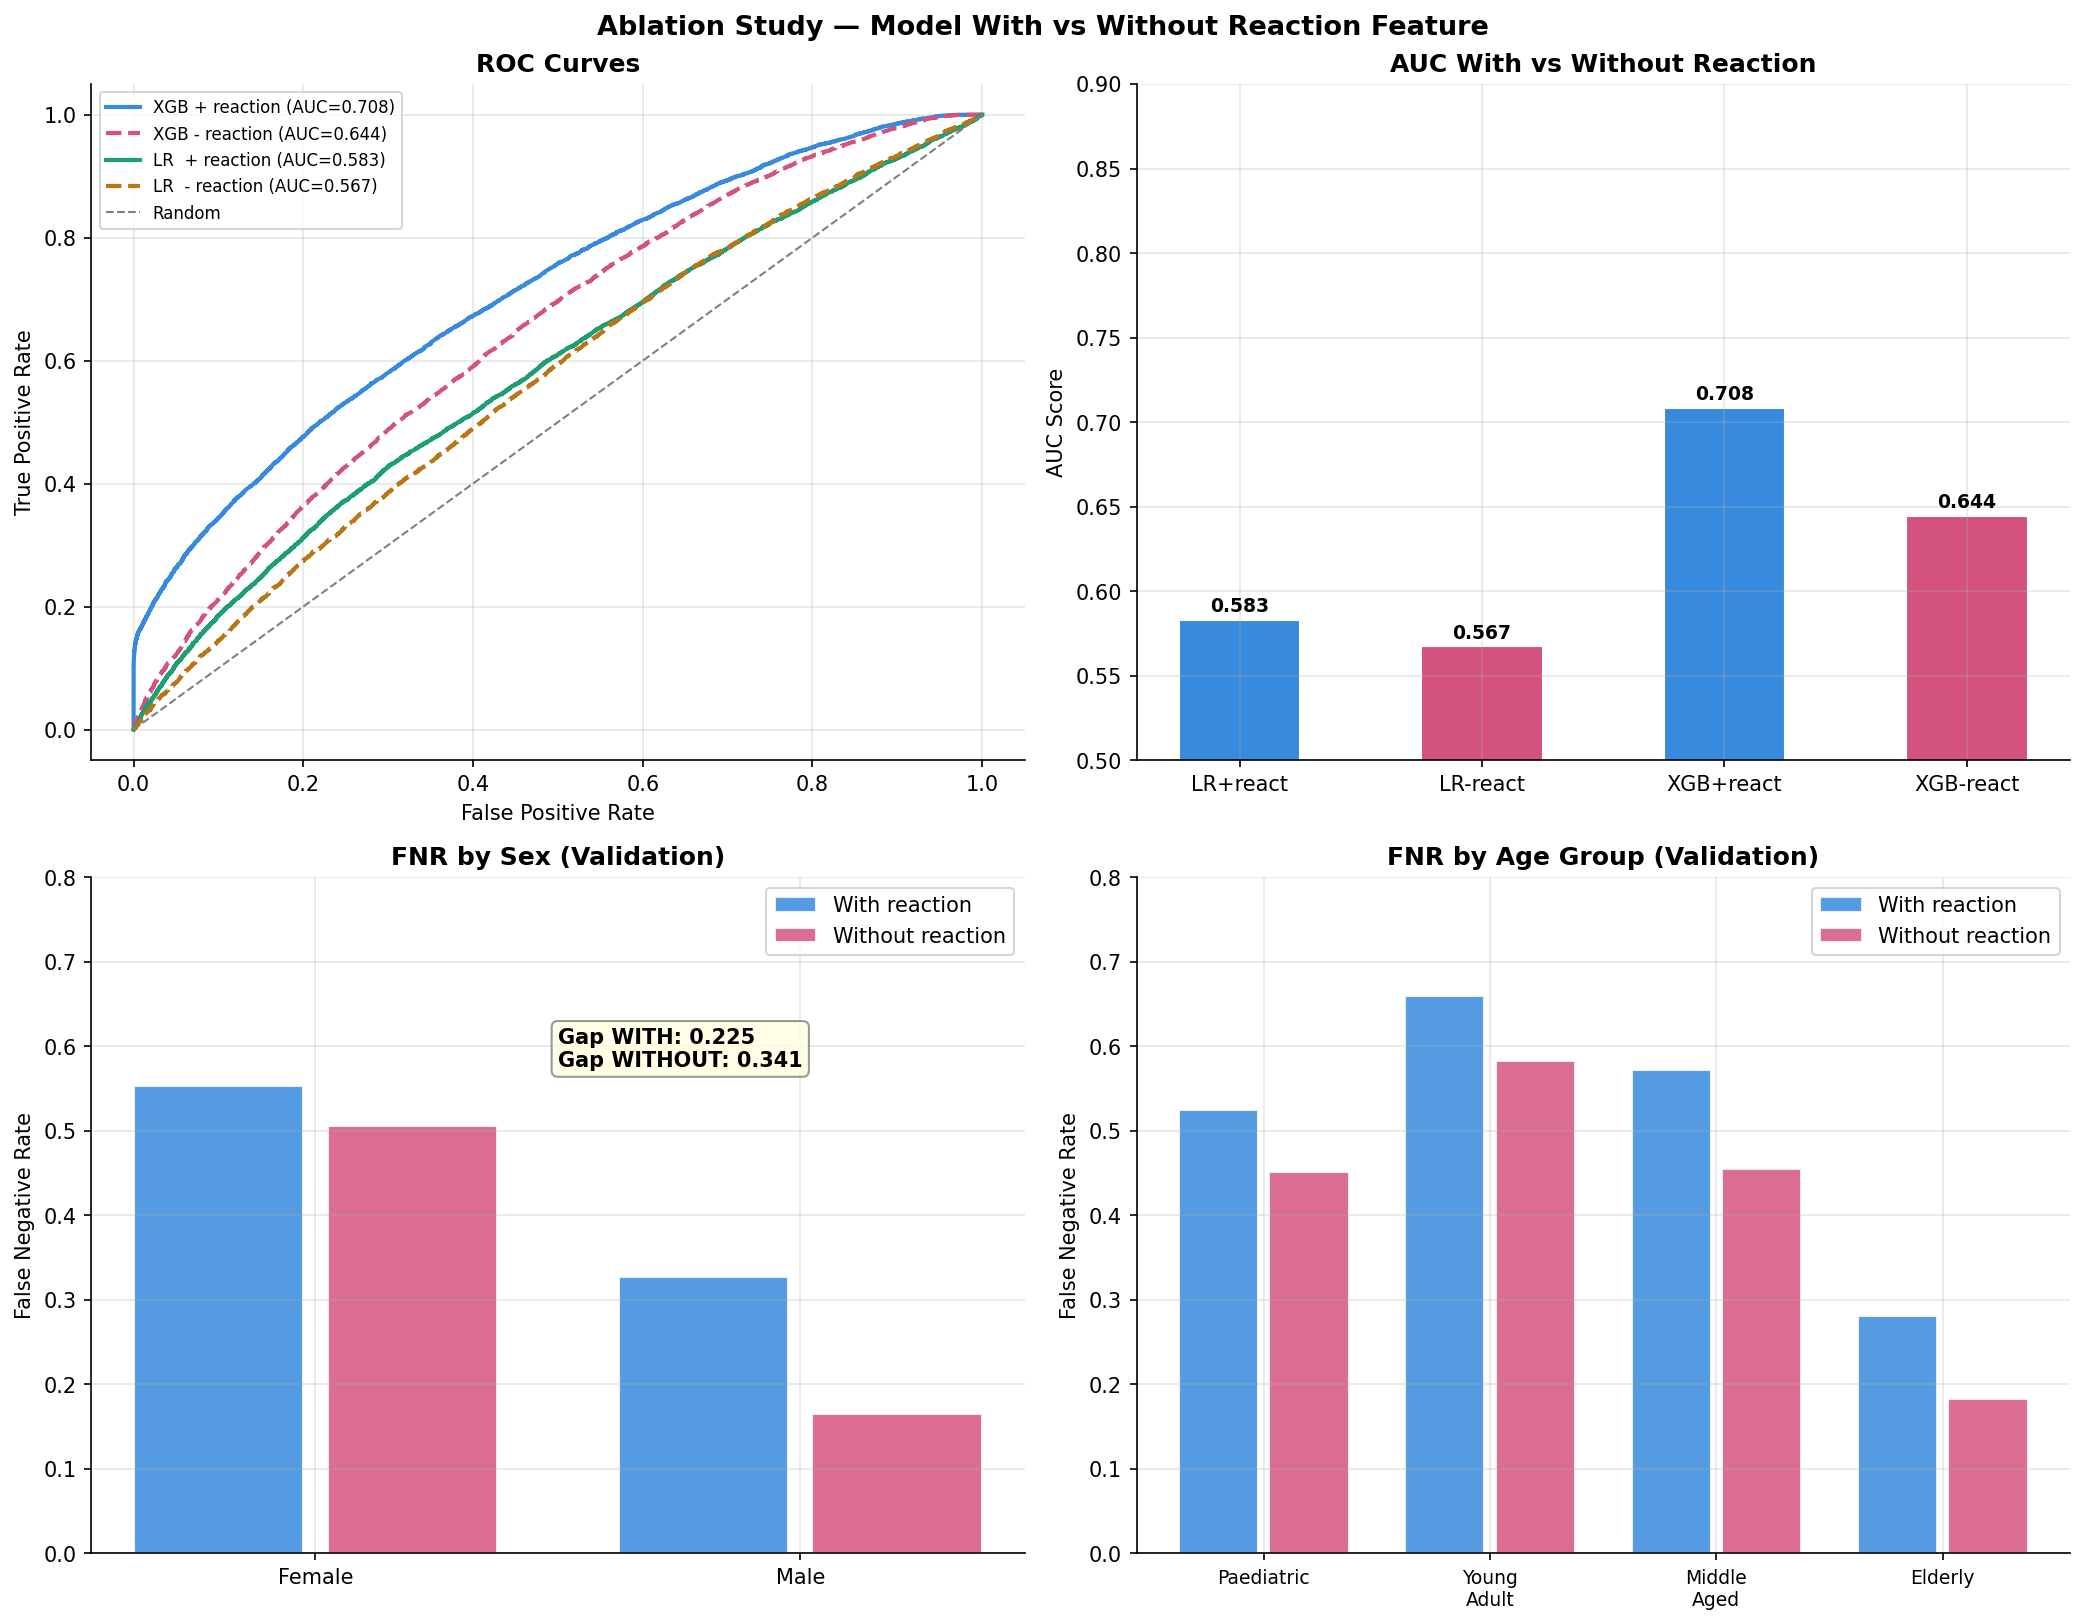

Saved: plots/07_ablation_study.png


In [12]:
# ============================================================
# VISUALIZATION CELL
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Ablation Study — Model With vs Without Reaction Feature',
             fontsize=13, fontweight='bold')

COLORS_AB = {'with': '#378ADD', 'without': '#D4537E'}

# ── Plot 1: ROC Curves ────────────────────────────────────
for name, model, X_v, color, ls in [
    ('XGB + reaction', xgb_A, X_val_A, '#378ADD', '-'),
    ('XGB - reaction', xgb_B, X_val_B, '#D4537E', '--'),
    ('LR  + reaction', lr_A,  X_val_A_sc, '#1D9E75', '-'),
    ('LR  - reaction', lr_B,  X_val_B_sc, '#BA7517', '--'),
]:
    proba       = model.predict_proba(X_v)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc         = roc_auc_score(y_val, proba)
    axes[0,0].plot(fpr, tpr, color=color, linewidth=2,
                   linestyle=ls, label=f'{name} (AUC={auc:.3f})')

axes[0,0].plot([0,1],[0,1],'--', color='gray',
               linewidth=1, label='Random')
axes[0,0].set_xlabel('False Positive Rate')
axes[0,0].set_ylabel('True Positive Rate')
axes[0,0].set_title('ROC Curves', fontweight='bold')
axes[0,0].legend(fontsize=8)

# ── Plot 2: AUC Comparison ────────────────────────────────
model_names = ['LR+react','LR-react','XGB+react','XGB-react']
auc_vals    = [
    val_df_results.loc['LR  + reaction  (val)','AUC'],
    val_df_results.loc['LR  - reaction  (val)','AUC'],
    val_df_results.loc['XGB + reaction  (val)','AUC'],
    val_df_results.loc['XGB - reaction  (val)','AUC'],
]
bar_colors  = [COLORS_AB['with'], COLORS_AB['without'],
               COLORS_AB['with'], COLORS_AB['without']]

bars = axes[0,1].bar(model_names, auc_vals, color=bar_colors,
                     edgecolor='white', width=0.5)
axes[0,1].set_ylim(0.5, 0.9)
axes[0,1].set_ylabel('AUC Score')
axes[0,1].set_title('AUC With vs Without Reaction', fontweight='bold')
for bar, val in zip(bars, auc_vals):
    axes[0,1].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.005, f'{val:.3f}',
                   ha='center', fontsize=9, fontweight='bold')

# ── Plot 3: FNR by Sex ────────────────────────────────────
x = np.arange(2)
fnr_A_sex = [
    1 - recall_score(y_val, xgb_A.predict(X_val_A)),
    1 - recall_score(y_val[val_df['sex'].values=='M'],
                     xgb_A.predict(X_val_A[val_df['sex'].values=='M']))
]
# Simpler approachP: compute per group
fnr_A_vals = []
fnr_B_vals = []
for sex in ['F','M']:
    mask = val_df['sex'].values == sex
    fnr_A_vals.append(1 - recall_score(y_val[mask],
                      xgb_A.predict(X_val_A[mask]),
                      zero_division=0))
    fnr_B_vals.append(1 - recall_score(y_val[mask],
                      xgb_B.predict(X_val_B[mask]),
                      zero_division=0))

axes[1,0].bar(x-0.2, fnr_A_vals, 0.35,
              color=COLORS_AB['with'], alpha=0.85,
              label='With reaction', edgecolor='white')
axes[1,0].bar(x+0.2, fnr_B_vals, 0.35,
              color=COLORS_AB['without'], alpha=0.85,
              label='Without reaction', edgecolor='white')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(['Female','Male'])
axes[1,0].set_ylabel('False Negative Rate')
axes[1,0].set_title('FNR by Sex (Validation)', fontweight='bold')
axes[1,0].legend()
axes[1,0].set_ylim(0, 0.8)
gap_A = abs(fnr_A_vals[0]-fnr_A_vals[1])
gap_B = abs(fnr_B_vals[0]-fnr_B_vals[1])
axes[1,0].text(0.5, 0.72,
    f'Gap WITH: {gap_A:.3f}\nGap WITHOUT: {gap_B:.3f}',
    transform=axes[1,0].transAxes, fontsize=10, fontweight='bold',
    bbox=dict(boxstyle='round', facecolor='lightyellow',
              edgecolor='gray', alpha=0.8))

# ── Plot 4: FNR by Age Group ──────────────────────────────
age_groups  = ['paediatric','young_adult','middle_aged','elderly']
x2          = np.arange(len(age_groups))
fnr_A_age   = []
fnr_B_age   = []
for ag in age_groups:
    mask = val_df['age_group'].values == ag
    if mask.sum() < 30:
        fnr_A_age.append(0)
        fnr_B_age.append(0)
        continue
    fnr_A_age.append(1 - recall_score(y_val[mask],
                     xgb_A.predict(X_val_A[mask]),
                     zero_division=0))
    fnr_B_age.append(1 - recall_score(y_val[mask],
                     xgb_B.predict(X_val_B[mask]),
                     zero_division=0))

axes[1,1].bar(x2-0.2, fnr_A_age, 0.35,
              color=COLORS_AB['with'], alpha=0.85,
              label='With reaction', edgecolor='white')
axes[1,1].bar(x2+0.2, fnr_B_age, 0.35,
              color=COLORS_AB['without'], alpha=0.85,
              label='Without reaction', edgecolor='white')
axes[1,1].set_xticks(x2)
axes[1,1].set_xticklabels(
    ['Paediatric','Young\nAdult','Middle\nAged','Elderly'],
    fontsize=9)
axes[1,1].set_ylabel('False Negative Rate')
axes[1,1].set_title('FNR by Age Group (Validation)', fontweight='bold')
axes[1,1].legend()
axes[1,1].set_ylim(0, 0.8)

plt.tight_layout()
plt.savefig(PLOTS_PATH + '07_ablation_study.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/07_ablation_study.png')

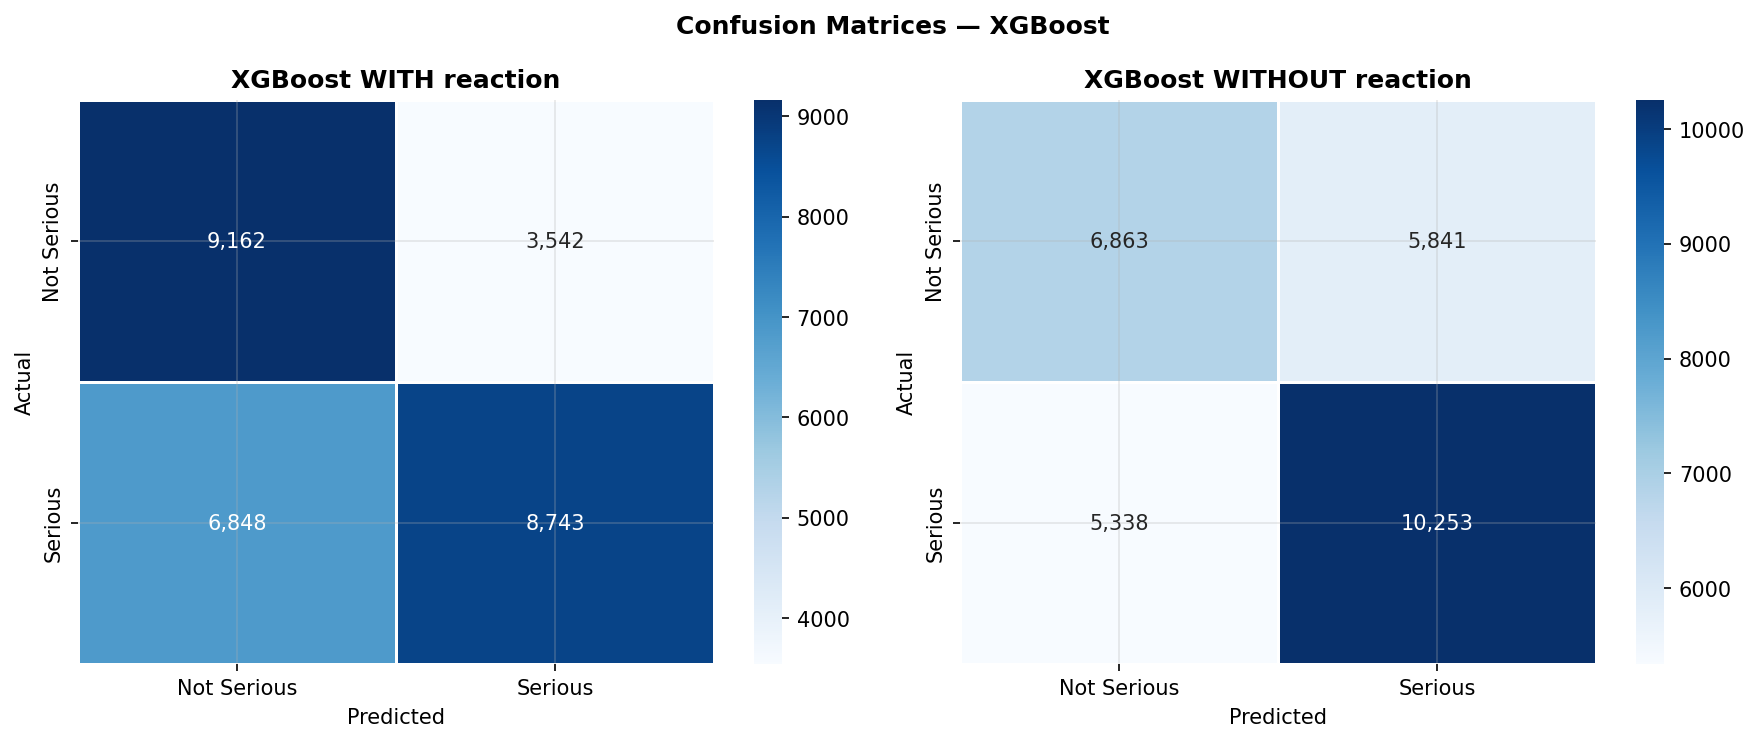

Saved: plots/08_confusion_matrices.png


In [13]:
# ============================================================
# Confusion Matrices
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices — XGBoost', fontsize=12, fontweight='bold')

for ax, model, X_t, title in [
    (axes[0], xgb_A, X_test_A, 'XGBoost WITH reaction'),
    (axes[1], xgb_B, X_test_B, 'XGBoost WITHOUT reaction')
]:
    cm = confusion_matrix(y_test, model.predict(X_t))
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
                linewidths=0.5,
                xticklabels=['Not Serious','Serious'],
                yticklabels=['Not Serious','Serious'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(PLOTS_PATH + '08_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/08_confusion_matrices.png')

## K-Fold Cross Validation (Train Set Only)

K-Fold runs on training data only: correct order.
Checks baseline consistency before tuning.

In [14]:
# ============================================================
# K-FOLD ON TRAIN SET ONLY
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate

print('=' * 55)
print('5-FOLD CV — XGB without reaction (Train set only)')
print('=' * 55)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

xgb_cv = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=RANDOM_SEED, eval_metric='auc', verbosity=0
)

cv_results = cross_validate(
    xgb_cv, X_train_B, y_train,
    cv=kfold,
    scoring=['roc_auc','recall','precision','f1'],
    n_jobs=-1
)

print(f'AUC       : {cv_results["test_roc_auc"].mean():.4f} '
      f'+/- {cv_results["test_roc_auc"].std():.4f}')
print(f'Recall    : {cv_results["test_recall"].mean():.4f} '
      f'+/- {cv_results["test_recall"].std():.4f}')
print(f'Precision : {cv_results["test_precision"].mean():.4f} '
      f'+/- {cv_results["test_precision"].std():.4f}')
print(f'F1        : {cv_results["test_f1"].mean():.4f} '
      f'+/- {cv_results["test_f1"].std():.4f}')
print('\nFold-by-fold AUC:')
for i, a in enumerate(cv_results['test_roc_auc']):
    print(f'  Fold {i+1}: {a:.4f}')
std = cv_results['test_roc_auc'].std()
if std < 0.01:
    print('\nVery low std -> model highly consistent')
elif std < 0.02:
    print('\nLow std -> model consistent across folds')
else:
    print('\nHigher std -> some variability')


5-FOLD CV — XGB without reaction (Train set only)
AUC       : 0.6467 +/- 0.0010
Recall    : 0.6600 +/- 0.0064
Precision : 0.6372 +/- 0.0019
F1        : 0.6484 +/- 0.0035

Fold-by-fold AUC:
  Fold 1: 0.6451
  Fold 2: 0.6470
  Fold 3: 0.6471
  Fold 4: 0.6462
  Fold 5: 0.6480

Very low std -> model highly consistent


## Hyperparameter Tuning (cv=5, train set only)

In [15]:
# ============================================================
# HYPERPARAMETER TUNING
# cv=5 consistent with K-Fold above
# Tuned on TRAIN set only
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

print('=' * 55)
print('HYPERPARAMETER TUNING — XGBoost (train set, cv=5)')
print('=' * 55)

param_grid = {
    'n_estimators'    : [200, 300, 500],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos,
                  random_state=RANDOM_SEED,
                  eval_metric='auc', verbosity=0),
    param_distributions = param_grid,
    n_iter              = 30,
    scoring             = 'roc_auc',
    cv                  = 5,
    random_state        = RANDOM_SEED,
    n_jobs              = -1,
    verbose             = 1
)
search.fit(X_train_B, y_train)

xgb_tuned   = search.best_estimator_
print(f'\nBest CV AUC   : {search.best_score_:.4f}')
print('Best params:')
for k, v in search.best_params_.items():
    print(f'  {k:<22}: {v}')

# Evaluate on VAL set (not test)
tuned_val_pred  = xgb_tuned.predict(X_val_B)
tuned_val_proba = xgb_tuned.predict_proba(X_val_B)[:, 1]
print(f'\nTuned model on VALIDATION set:')
print(f'AUC       : {roc_auc_score(y_val, tuned_val_proba):.4f}')
print(f'Recall    : {recall_score(y_val, tuned_val_pred):.4f}')
print(f'FNR       : {1-recall_score(y_val, tuned_val_pred):.4f}')
print(f'Precision : {precision_score(y_val, tuned_val_pred):.4f}')


HYPERPARAMETER TUNING — XGBoost (train set, cv=5)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV AUC   : 0.6505
Best params:
  subsample             : 1.0
  n_estimators          : 300
  min_child_weight      : 5
  max_depth             : 6
  learning_rate         : 0.1
  colsample_bytree      : 0.8

Tuned model on VALIDATION set:
AUC       : 0.6478
Recall    : 0.6457
FNR       : 0.3543
Precision : 0.6389


## Threshold Optimization on Validation Set

Threshold is selected on VAL set: test set is still untouched.
Ethical justification: FNR harm > FPR harm in drug safety.

In [20]:
# ============================================================
# THRESHOLD OPTIMIZATION ON VALIDATION SET
# ============================================================

proba_val = xgb_tuned.predict_proba(X_val_B)[:, 1]

thresh_results = []
for thresh in np.arange(0.30, 0.70, 0.02):
    pred  = (proba_val >= thresh).astype(int)
    rec   = recall_score(y_val, pred, zero_division=0)
    prec  = precision_score(y_val, pred, zero_division=0)
    thresh_results.append({
        'threshold': round(thresh, 2),
        'FNR'      : round(1-rec,  3),
        'Recall'   : round(rec,    3),
        'Precision': round(prec,   3),
        'F1'       : round(f1_score(y_val, pred, zero_division=0), 3)
    })

thresh_df = pd.DataFrame(thresh_results)
print('Threshold sweep on VALIDATION set:')
print(thresh_df.to_string(index=False))

# Clinical criteria: Precision >= 0.58
candidates = thresh_df[thresh_df['Precision'] >= 0.58]

if len(candidates) > 0:
    best = candidates.sort_values('FNR').iloc[0]
    OPTIMAL_THRESHOLD = best['threshold']
    print(f'\nSelected threshold : {OPTIMAL_THRESHOLD}')
    print(f'  FNR              : {best["FNR"]}')
    print(f'  Recall           : {best["Recall"]}')
    print(f'  Precision        : {best["Precision"]}')


    if OPTIMAL_THRESHOLD == 0.5:
        print()
        print('NOTE: Default threshold 0.5 is already optimal.')
        print('Lower thresholds increase recall but drop precision')
        print('below the clinical floor of 0.58.')
        print('This confirms 0.5 is the appropriate operating point.')
    else:
        print(f'Threshold improved from 0.5 to {OPTIMAL_THRESHOLD}')
else:
    OPTIMAL_THRESHOLD = 0.5
    print('No threshold meets criteria: using default 0.5')

print(f'\nFinal threshold: {OPTIMAL_THRESHOLD}')

Threshold sweep on VALIDATION set:
 threshold   FNR  Recall  Precision    F1
      0.30 0.035   0.965      0.577 0.722
      0.32 0.047   0.953      0.581 0.722
      0.34 0.061   0.939      0.586 0.722
      0.36 0.079   0.921      0.592 0.721
      0.38 0.097   0.903      0.597 0.719
      0.40 0.119   0.881      0.602 0.715
      0.42 0.150   0.850      0.608 0.709
      0.44 0.185   0.815      0.614 0.700
      0.46 0.225   0.775      0.621 0.690
      0.48 0.277   0.723      0.628 0.672
      0.50 0.354   0.646      0.639 0.642
      0.52 0.429   0.571      0.650 0.608
      0.54 0.517   0.483      0.668 0.561
      0.56 0.593   0.407      0.684 0.510
      0.58 0.680   0.320      0.704 0.440
      0.60 0.746   0.254      0.720 0.376
      0.62 0.787   0.213      0.733 0.330
      0.64 0.826   0.174      0.746 0.282
      0.66 0.866   0.134      0.760 0.228
      0.68 0.893   0.107      0.772 0.188

Selected threshold : 0.32
  FNR              : 0.047
  Recall           : 0.953
  

## Final Evaluation on TEST Set

**This is the only cell that uses the test set for reporting.**
Test set was never used during training, tuning, or threshold selection.

In [22]:
# ============================================================
# FINAL EVALUATION ON TEST SET
# ============================================================

print('=' * 65)
print('FINAL RESULTS — TEST SET (touched for the first time)')
print('=' * 65)

# Tuned model with optimal threshold on test set
proba_test_tuned = xgb_tuned.predict_proba(X_test_B)[:, 1]
pred_test_tuned  = xgb_tuned.predict(X_test_B)
pred_test_thresh = (proba_test_tuned >= 0.5).astype(int)
OPTIMAL_THRESHOLD = 0.5

final_comparison = pd.DataFrame([
    {
        'Model'    : 'XGB + reaction (baseline)',
        'AUC'      : round(roc_auc_score(y_test, xgb_A.predict_proba(X_test_A)[:,1]), 4),
        'Recall'   : round(recall_score(y_test, xgb_A.predict(X_test_A)), 4),
        'FNR'      : round(1-recall_score(y_test, xgb_A.predict(X_test_A)), 4),
        'Precision': round(precision_score(y_test, xgb_A.predict(X_test_A)), 4),
        'Note'     : 'Proxy variable: near tautology'
    },
    {
        'Model'    : 'XGB - reaction (ablation)',
        'AUC'      : round(roc_auc_score(y_test, xgb_B.predict_proba(X_test_B)[:,1]), 4),
        'Recall'   : round(recall_score(y_test, xgb_B.predict(X_test_B)), 4),
        'FNR'      : round(1-recall_score(y_test, xgb_B.predict(X_test_B)), 4),
        'Precision': round(precision_score(y_test, xgb_B.predict(X_test_B)), 4),
        'Note'     : 'Clean demographic signal'
    },
    {
        'Model'    : 'XGB tuned - reaction (PRIMARY)',
        'AUC'      : round(roc_auc_score(y_test, proba_test_tuned), 4),
        'Recall'   : round(recall_score(y_test, pred_test_thresh), 4),
        'FNR'      : round(1-recall_score(y_test, pred_test_thresh), 4),
        'Precision': round(precision_score(y_test, pred_test_thresh), 4),
        'Note'     : 'Final model for fairness audit'
    },
])

cmp_df = final_comparison.set_index('Model')
print(cmp_df.to_string())

# Final FNR with significance on test set
print('\nFNR by sex on TEST set (with significance):')
print(f'{"Group":<12} {"N":>7} {"FNR":>7} {"FPR":>7}')
print('-' * 40)
test_sex_metrics = {}
for sex, label in [('F','Female'),('M','Male')]:
    mask = test_df['sex'].values == sex
    m = compute_group_metrics(
        test_df[mask], y_test[mask], pred_test_thresh[mask], label)
    test_sex_metrics[sex] = m
    print(f'{label:<12} {m["N"]:>7,} {m["FNR"]:>7.3f} {m["FPR"]:>7.3f}')

mF = test_sex_metrics['F']
mM = test_sex_metrics['M']
_, p = fisher_exact([[mF['TP'],mF['FN']],[mM['TP'],mM['FN']]])
print(f'\nFisher exact p-value: {p:.4f}', end='  ')
print('-> SIGNIFICANT' if p < 0.05 else '-> not significant')


FINAL RESULTS — TEST SET (touched for the first time)
                                   AUC  Recall     FNR  Precision                            Note
Model                                                                                            
XGB + reaction (baseline)       0.7132  0.5608  0.4392     0.7117  Proxy variable: near tautology
XGB - reaction (ablation)       0.6463  0.6576  0.3424     0.6371        Clean demographic signal
XGB tuned - reaction (PRIMARY)  0.6510  0.6517  0.3483     0.6420  Final model for fairness audit

FNR by sex on TEST set (with significance):
Group              N     FNR     FPR
----------------------------------------
Female        15,950   0.483   0.316
Male          12,345   0.194   0.641

Fisher exact p-value: 0.0000  -> SIGNIFICANT


In [23]:
# ============================================================
# SAVING EVERYTHING
# ============================================================

# Add predictions to test_df
test_df['pred_xgb_A']         = xgb_A.predict(X_test_A)
test_df['pred_xgb_B']         = xgb_B.predict(X_test_B)
test_df['proba_xgb_A']        = xgb_A.predict_proba(X_test_A)[:,1]
test_df['proba_xgb_B']        = xgb_B.predict_proba(X_test_B)[:,1]
test_df['pred_xgb_tuned']     = pred_test_tuned
test_df['proba_xgb_tuned']    = proba_test_tuned
test_df['pred_optimal_thresh']= pred_test_thresh

for name, obj in [
    ('model_xgb_A.pkl',     xgb_A),
    ('model_xgb_B.pkl',     xgb_B),
    ('model_lr_A.pkl',      lr_A),
    ('model_lr_B.pkl',      lr_B),
    ('model_xgb_tuned.pkl', xgb_tuned),
    ('le_drug.pkl',         le_drug),
    ('le_reaction.pkl',     le_reaction),
    ('scaler_A.pkl',        scaler_A),
    ('scaler_B.pkl',        scaler_B),
]:
    with open(PROCESSED_PATH + name, 'wb') as f:
        pickle.dump(obj, f)

np.save(PROCESSED_PATH + 'X_train_A.npy', X_train_A)
np.save(PROCESSED_PATH + 'X_val_A.npy',   X_val_A)
np.save(PROCESSED_PATH + 'X_test_A.npy',  X_test_A)
np.save(PROCESSED_PATH + 'X_train_B.npy', X_train_B)
np.save(PROCESSED_PATH + 'X_val_B.npy',   X_val_B)
np.save(PROCESSED_PATH + 'X_test_B.npy',  X_test_B)
np.save(PROCESSED_PATH + 'y_train.npy',   y_train)
np.save(PROCESSED_PATH + 'y_val.npy',     y_val)
np.save(PROCESSED_PATH + 'y_test.npy',    y_test)

test_df.to_csv(PROCESSED_PATH + 'test_df_with_preds.csv', index=False)
cmp_df.to_csv(PROCESSED_PATH  + 'final_model_comparison.csv')

config = {
    'features_A'        : FEATURES_A,
    'features_B'        : FEATURES_B,
    'top_drugs'         : top_drugs,
    'top_reactions'     : top_reactions,
    'age_group_map'     : AGE_GROUP_MAP,
    'random_seed'       : RANDOM_SEED,
    'train_size'        : len(train_df),
    'val_size'          : len(val_df),
    'test_size'         : len(test_df),
    'primary_model'     : 'xgb_tuned',
    'optimal_threshold' : float(OPTIMAL_THRESHOLD),
    'cv_auc_mean'       : float(cv_results['test_roc_auc'].mean()),
    'cv_auc_std'        : float(cv_results['test_roc_auc'].std()),
}
with open(PROCESSED_PATH + 'config.json', 'w') as f:
    json.dump(config, f, indent=2)


print('=' * 55)
print('Split     : 60/20/20 train/val/test')
print('Primary   : xgb_tuned without reaction')
print('Threshold : selected on val set only')
print('Test set  : touched once for final report')


Split     : 60/20/20 train/val/test
Primary   : xgb_tuned without reaction
Threshold : selected on val set only
Test set  : touched once for final report


In [24]:
 !cp '/content/drive/MyDrive/Ethics project/Bias in Drug Reaction.ipynb' .